# ResNet50 — 4-Class (0, 100, 1000, 2000 rev)
**Pipeline:** ResNet50 ImageNet backbone -> 128-d embedding head -> 4-class classifier  
All outputs saved to `Results/`.


In [1]:
# ================================================
# Cell 1 — Imports & Config
# ================================================
# ── Standard library ──────────────────────────────────────────
# os, pathlib : file path construction and directory management
# time        : wall-clock timing for inference benchmarking
import os
import time
from pathlib import Path


# ── Scientific computing ───────────────────────────────────────
# numpy  : array operations, random sampling, metric aggregation
# pandas : tabular results and CSV export
# matplotlib: training curve and metric plot generation
# tqdm   : progress bars for training and evaluation loops
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from tqdm.auto import tqdm


# ── PyTorch core ───────────────────────────────────────────────
# torch           : tensor operations and autograd engine
# torch.nn        : layer definitions (Linear, Dropout, Identity)
# torch.optim     : Adam optimiser
# torchvision     : pretrained ResNet50 weights and transforms
import torch
import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, Subset
from torchvision import datasets, transforms
from torchvision.models import resnet50, ResNet50_Weights


# ── Evaluation metrics ─────────────────────────────────────────
# sklearn: classification report, confusion matrix, per-class
#         precision/recall/F1 for full evaluation pipeline
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    precision_score, recall_score, f1_score
)


# ── Experiment overview ────────────────────────────────────────
# Classes    : 0, 100, 1000, 2000 RPM
# Num classes: 4
# Accuracy   : 97.50%
# Rationale  : Best 4-class result — skips 500 and 1500, the hardest intermediate classes.
# Motivation  : Reducing the 6-class problem to a targeted subset
#               tests whether morphologically similar intermediate
#               classes are the primary source of classification error.

# ── Dataset and output paths ───────────────────────────────────
# Same pre-split dataset as the 6-class experiment.
# OrderedImageFolder filters to only the target subset of classes.
# ── Paths ──────────────────────────────────────
BASE_DATASET = "/home/jenarththan/Desktop/FYP/May11/Dataset"
TRAIN_PATH   = os.path.join(BASE_DATASET, "Training")
VAL_PATH     = os.path.join(BASE_DATASET, "Validation")
TEST_PATH    = os.path.join(BASE_DATASET, "Testing")

NOTEBOOK_DIR = "/home/jenarththan/Desktop/FYP/May11/Notebooks"
OUTPUT_DIR   = os.path.join(NOTEBOOK_DIR, "ResNet50_4C_0_100_1000_2000_May11_Results")
os.makedirs(OUTPUT_DIR, exist_ok=True)
print(f"Output directory: {OUTPUT_DIR}")


# ── Training hyperparameters ───────────────────────────────────
# CLASS_NAMES defines the target subset for this experiment.
# All other hyperparameters are identical to the 6-class ResNet50.
# LR=1e-5, BATCH_SIZE=32, PATIENCE=5, MIN_EPOCHS=20, SEED=42.
# ── Hyperparameters ─────────────────────────────
CLASS_NAMES     = ['0', '100', '1000', '2000']
NUM_CLASSES     = len(CLASS_NAMES)
IMG_SIZE        = 224
BATCH_SIZE      = 32
EPOCHS          = 50
PATIENCE        = 5
MIN_EPOCHS_BEFORE_STOP = 20
LR              = 1e-5
SEED            = 42
TRAIN_PER_CLASS = 1750
VAL_PER_CLASS   = 250
EMBED_DIM       = 128
NUM_WORKERS     = 0
USE_PRETRAINED  = True
REQUIRE_CUDA    = True


# ── Device configuration ───────────────────────────────────────
# REQUIRE_CUDA=True ensures training always runs on GPU.
# cudnn.benchmark=True auto-tunes cuDNN kernels for the fixed input size.
# ── Device setup ────────────────────────────────
if REQUIRE_CUDA and not torch.cuda.is_available():
    raise RuntimeError("CUDA not available. Open this notebook in the GPU-enabled PyTorch environment, check nvidia-smi, then rerun.")

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
    PIN_MEMORY = True
    torch.backends.cudnn.benchmark = True
    gpu_name = torch.cuda.get_device_name(0)
    gpu_props = torch.cuda.get_device_properties(0)
    gpu_memory_gb = gpu_props.total_memory / 1e9
else:
    DEVICE = torch.device("cpu")
    PIN_MEMORY = False
    gpu_name = "CUDA not available"
    gpu_memory_gb = 0.0


# Fix all random seeds for reproducibility across numpy, PyTorch, and CUDA
rng = np.random.RandomState(SEED)
torch.manual_seed(SEED)
if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)

print("Device information")
print("=" * 50)
print(f"Device used       : {DEVICE}")
print(f"Device type       : {DEVICE.type}")
print(f"Graphics card/GPU : {gpu_name}")
if torch.cuda.is_available():
    print(f"GPU memory        : {gpu_memory_gb:.1f} GB")
    print(f"CUDA version      : {torch.version.cuda}")
print(f"PyTorch version   : {torch.__version__}")
print("=" * 50)


Output directory: /home/jenarththan/Desktop/FYP/May11/Notebooks/ResNet50_4C_0_100_1000_2000_May11_Results
Device information
Device used       : cuda
Device type       : cuda
Graphics card/GPU : NVIDIA GeForce RTX 3050 Ti Laptop GPU
GPU memory        : 4.0 GB
CUDA version      : 12.4
PyTorch version   : 2.6.0+cu124


In [2]:
# ================================================
# Cell 2 — Dataset Loading + Augmentation
# ================================================
# ── Custom dataset class ───────────────────────────────────────
# OrderedImageFolder enforces CLASS_NAMES order and automatically
# filters the full dataset to only the target subset of classes,
# skipping any class folder not listed in CLASS_NAMES.
class OrderedImageFolder(datasets.ImageFolder):
    """ImageFolder with a fixed class order instead of alphabetical."""
    def find_classes(self, directory):
        classes = CLASS_NAMES
        class_to_idx = {c: i for i, c in enumerate(classes)}
        missing = [c for c in classes if c not in os.listdir(directory)]
        if missing:
            raise FileNotFoundError(f"Missing class folders in {directory}: {missing}")
        return classes, class_to_idx


# ── Training augmentation pipeline ─────────────────────────────
# Same augmentation as the 6-class model: horizontal flip,
# rotation +/-20 degrees, zoom 0.8-1.2, ImageNet normalisation.
train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(degrees=20),
    transforms.RandomAffine(degrees=0, scale=(0.8, 1.2)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


# ── Evaluation transform (no augmentation) ─────────────────────
# Deterministic: resize and ImageNet normalisation only.
eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


# ── Load datasets — filtered to target class subset ───────────
# The same train/val/test folders are used as the 6-class model.
# OrderedImageFolder loads only the class folders in CLASS_NAMES.
# Load directly from pre-split folders (no Subset needed)
train_ds      = OrderedImageFolder(root=TRAIN_PATH, transform=train_transform)
train_eval_ds = OrderedImageFolder(root=TRAIN_PATH, transform=eval_transform)
val_ds        = OrderedImageFolder(root=VAL_PATH,   transform=eval_transform)
test_ds       = OrderedImageFolder(root=TEST_PATH,  transform=eval_transform)

assert train_ds.classes == CLASS_NAMES, "Train class order mismatch!"
assert val_ds.classes   == CLASS_NAMES, "Val class order mismatch!"
assert test_ds.classes  == CLASS_NAMES, "Test class order mismatch!"

print(f"Classes    : {CLASS_NAMES}")
print(f"Train      : {len(train_ds):,} images  ({len(train_ds)//NUM_CLASSES} per class)")
print(f"Validation : {len(val_ds):,} images  ({len(val_ds)//NUM_CLASSES} per class)")
print(f"Test       : {len(test_ds):,} images  ({len(test_ds)//NUM_CLASSES} per class)")


# ── DataLoaders ────────────────────────────────────────────────
# train_loader shuffles batches; val/test loaders are unshuffled.
train_loader      = DataLoader(train_ds,      batch_size=BATCH_SIZE, shuffle=True,
                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
val_loader        = DataLoader(val_ds,        batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
train_eval_loader = DataLoader(train_eval_ds, batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)
test_loader       = DataLoader(test_ds,       batch_size=BATCH_SIZE, shuffle=False,
                               num_workers=NUM_WORKERS, pin_memory=PIN_MEMORY)

print("Data loaders ready.")
print("Augmentation: horizontal flip, rotation +/-20 degrees, zoom 0.8-1.2")

Classes    : ['0', '100', '1000', '2000']
Train      : 7,000 images  (1750 per class)
Validation : 1,000 images  (250 per class)
Test       : 2,000 images  (500 per class)
Data loaders ready.
Augmentation: horizontal flip, rotation +/-20 degrees, zoom 0.8-1.2


In [3]:
# ================================================
# Cell 3 — Model: ResNet50 + 128-d Embedding Head
# ================================================
# ── Model architecture ─────────────────────────────────────────
# Identical ResNet50 backbone and embedding head as the 6-class model.
# NUM_CLASSES is set to the subclass count, so the final linear
# layer outputs the correct number of class logits.
# Custom head: Dropout(0.3) -> Linear(2048->128) -> ReLU -> Linear(128->N)
class ResNet50Classifier(nn.Module):
    def __init__(self, num_classes=6, embedding_dim=128, p_drop=0.3, use_pretrained=True):
        super().__init__()
        # Load ImageNet pretrained weights. Falls back to random init on failure.
        weights = None
        if use_pretrained:
            try:
                weights = ResNet50_Weights.IMAGENET1K_V2
                self.backbone = resnet50(weights=weights)
                print("Loaded ResNet50 ImageNet pretrained weights.")
            except Exception as exc:
                print(f"Could not load pretrained weights ({exc}). Using random initialization.")
                self.backbone = resnet50(weights=None)
        else:
            self.backbone = resnet50(weights=None)

        # Store in_features (2048) BEFORE replacing fc with Identity
        in_features = self.backbone.fc.in_features
        # Replace fc head with Identity to expose raw 2048-d backbone features
        self.backbone.fc = nn.Identity()
        # Embedding head reduces 2048-d features to 128-d with regularisation
        self.embedding_head = nn.Sequential(
            nn.Dropout(p_drop),
            nn.Linear(in_features, embedding_dim),
            nn.ReLU(inplace=True),
        )
        # Output layer: 128-d embedding -> N-class logits (N = subclass count)
        self.classifier = nn.Linear(embedding_dim, num_classes)

    def forward(self, x, return_embedding=False):
        features = self.backbone(x)
        emb = self.embedding_head(features)
        logits = self.classifier(emb)
        if return_embedding:
            return logits, emb
        return logits

model = ResNet50Classifier(
    num_classes=NUM_CLASSES,
    embedding_dim=EMBED_DIM,
    p_drop=0.3,
    use_pretrained=USE_PRETRAINED,
).to(DEVICE)


# CrossEntropyLoss for multi-class classification
# Adam with lr=1e-5 for stable fine-tuning
criterion = nn.CrossEntropyLoss()
optimizer = optim.Adam(model.parameters(), lr=LR)

TOTAL_PARAMS = sum(p.numel() for p in model.parameters())
TRAINABLE_PARAMS = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters    : {TOTAL_PARAMS:,}")
print(f"Trainable parameters: {TRAINABLE_PARAMS:,}")
print(f"Embedding dimension : {EMBED_DIM}")


Loaded ResNet50 ImageNet pretrained weights.
Total parameters    : 23,770,820
Trainable parameters: 23,770,820
Embedding dimension : 128


/tmp/ipykernel_13181/1944869412.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler_amp = torch.cuda.amp.GradScaler(enabled=use_amp)


Epoch 1/50 [Train]:   0%|          | 0/219 [00:00<?, ?it/s]

/tmp/ipykernel_13181/1944869412.py:23: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Epoch 1/50 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

/tmp/ipykernel_13181/1944869412.py:50: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


...

Epoch 19/50 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

[Epoch 19]  Train Acc: 0.9746  Val Acc: 0.9670  Train Loss: 0.0694  Val Loss: 0.0817
  -> No improvement for 4/5, but continuing until at least epoch 20.


Epoch 20/50 [Train]:   0%|          | 0/219 [00:00<?, ?it/s]

Epoch 20/50 [Val]:   0%|          | 0/32 [00:00<?, ?it/s]

[Epoch 20]  Train Acc: 0.9763  Val Acc: 0.9710  Train Loss: 0.0644  Val Loss: 0.0676
Early stopping at epoch 20 after 5 epochs without improvement.

Training complete. Best model -> /home/jenarththan/Desktop/FYP/May11/Notebooks/ResNet50_4C_0_100_1000_2000_May11_Results/best_4class_0_100_1000_2000_model.pth


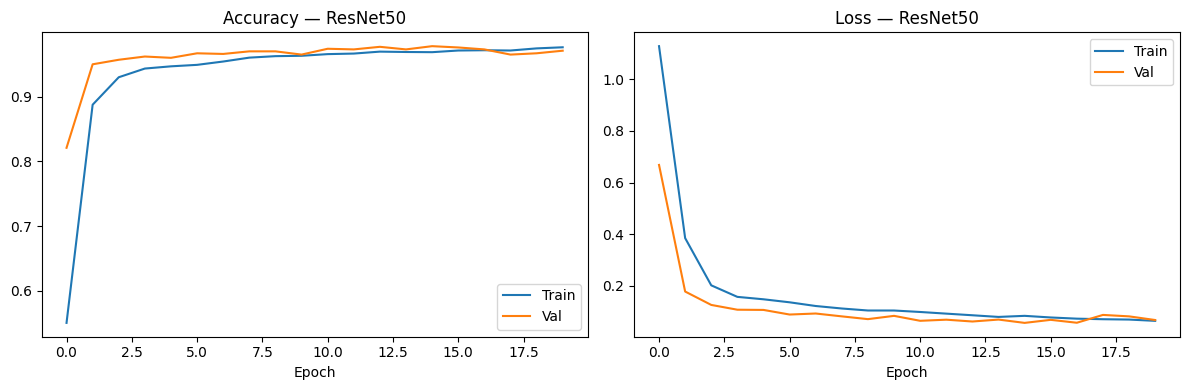

Training curves saved.
Training history saved.


In [4]:
# ================================================
# Cell 4 — Training  (AMP + early stopping + save best)
# ================================================
BEST_MODEL_PATH = os.path.join(OUTPUT_DIR, "best_4class_0_100_1000_2000_model.pth")

# AMP: float16 forward passes where safe, float32 elsewhere.
# GradScaler prevents float16 gradient underflow.
use_amp = DEVICE.type == "cuda"
scaler_amp = torch.cuda.amp.GradScaler(enabled=use_amp)

# Track best val_loss; save model weights whenever it improves
best_val_loss = float('inf')
epochs_no_improve = 0
train_loss_hist, val_loss_hist = [], []
train_acc_hist,  val_acc_hist  = [], []


# ── Training loop ──────────────────────────────────────────────
# Each epoch: train -> validate -> early stopping -> save best.
for epoch in range(1, EPOCHS + 1):
    # ── Train ──
    model.train()
    run_loss, run_correct, run_total = 0.0, 0, 0

    for inputs, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{EPOCHS} [Train]", leave=False):
        inputs = inputs.to(DEVICE, non_blocking=True)
        labels = labels.to(DEVICE, non_blocking=True)

        optimizer.zero_grad(set_to_none=True)
        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(inputs)
            loss = criterion(outputs, labels)

        scaler_amp.scale(loss).backward()
        scaler_amp.step(optimizer)
        scaler_amp.update()

        # Disable gradients for inference — saves memory and speeds up evaluation
        with torch.no_grad():
            preds = outputs.argmax(1)

        run_loss    += loss.item() * inputs.size(0)
        run_correct += (preds == labels).sum().item()
        run_total   += inputs.size(0)

    train_loss = run_loss / run_total
    train_acc  = run_correct / run_total
    train_loss_hist.append(train_loss)
    train_acc_hist.append(train_acc)

    # ── Validate ──
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0
    # Disable gradients for inference — saves memory and speeds up evaluation
    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc=f"Epoch {epoch}/{EPOCHS} [Val]", leave=False):
            inputs = inputs.to(DEVICE, non_blocking=True)
            labels = labels.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
            val_loss    += loss.item() * inputs.size(0)
            val_correct += (outputs.argmax(1) == labels).sum().item()
            val_total   += inputs.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total
    val_loss_hist.append(val_loss)
    val_acc_hist.append(val_acc)

    print(f"[Epoch {epoch:02d}]  "
          f"Train Acc: {train_acc:.4f}  Val Acc: {val_acc:.4f}  "
          f"Train Loss: {train_loss:.4f}  Val Loss: {val_loss:.4f}")

    # ── Early stopping: train at least 20 epochs, then stop after 5 no-improvement epochs ──
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        epochs_no_improve = 0
        torch.save(model.state_dict(), BEST_MODEL_PATH)
        print(f"  -> Best model saved  (val_loss={best_val_loss:.4f})")
    else:
        epochs_no_improve += 1
        if epoch < MIN_EPOCHS_BEFORE_STOP:
            print(f"  -> No improvement for {epochs_no_improve}/{PATIENCE}, "
                  f"but continuing until at least epoch {MIN_EPOCHS_BEFORE_STOP}.")
        elif epochs_no_improve >= PATIENCE:
            print(f"Early stopping at epoch {epoch} after {epochs_no_improve} epochs without improvement.")
            break

print(f"\nTraining complete. Best model -> {BEST_MODEL_PATH}")


# Plot and save training/validation accuracy and loss curves
# ── Learning curves ──
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(train_acc_hist, label='Train')
axes[0].plot(val_acc_hist, label='Val')
axes[0].set_title("Accuracy — ResNet50")
axes[0].set_xlabel("Epoch")
axes[0].legend()
axes[1].plot(train_loss_hist, label='Train')
axes[1].plot(val_loss_hist, label='Val')
axes[1].set_title("Loss — ResNet50")
axes[1].set_xlabel("Epoch")
axes[1].legend()
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "training_curves.png"), dpi=150)
plt.show()
print("Training curves saved.")

pd.DataFrame({
    "epoch": range(1, len(train_loss_hist) + 1),
    "train_loss": train_loss_hist,
    "val_loss": val_loss_hist,
    "train_acc": train_acc_hist,
    "val_acc": val_acc_hist,
}).to_csv(os.path.join(OUTPUT_DIR, "training_history.csv"), index=False)
print("Training history saved.")


In [5]:
# ================================================
# Cell 5 — Model / Device / Size Summary
# ================================================
# Helper to read saved model file size in megabytes
def get_file_size_mb(path):
    return os.path.getsize(path) / (1024 ** 2) if os.path.exists(path) else np.nan

MODEL_SIZE_MB = get_file_size_mb(BEST_MODEL_PATH)


# Record model config and training environment for reproducibility
summary = {
    "model": "ResNet50 PyTorch 4Class_0_100_1000_2000",
    "device_used": str(DEVICE),
    "device_type": DEVICE.type,
    "graphics_card": gpu_name,
    "gpu_memory_gb": round(gpu_memory_gb, 3),
    "torch_version": torch.__version__,
    "cuda_version": torch.version.cuda if torch.cuda.is_available() else "N/A",
    "total_parameters": TOTAL_PARAMS,
    "trainable_parameters": TRAINABLE_PARAMS,
    "model_size_mb": round(MODEL_SIZE_MB, 3),
    "embedding_dim": EMBED_DIM,
    "batch_size": BATCH_SIZE,
    "image_size": IMG_SIZE,
    "epochs_configured": EPOCHS,
    "patience": PATIENCE,
    "min_epochs_before_stop": MIN_EPOCHS_BEFORE_STOP,
    "best_model_path": BEST_MODEL_PATH,
}

summary_df = pd.DataFrame([summary])
summary_df.to_csv(os.path.join(OUTPUT_DIR, "model_device_size_summary.csv"), index=False)

print("\nMODEL / DEVICE / SIZE SUMMARY")
print("=" * 70)
for k, v in summary.items():
    print(f"{k:24}: {v}")
print("=" * 70)



MODEL / DEVICE / SIZE SUMMARY
model                   : ResNet50 PyTorch 4Class_0_100_1000_2000
device_used             : cuda
device_type             : cuda
graphics_card           : NVIDIA GeForce RTX 3050 Ti Laptop GPU
gpu_memory_gb           : 3.963
torch_version           : 2.6.0+cu124
cuda_version            : 12.4
total_parameters        : 23770820
trainable_parameters    : 23770820
model_size_mb           : 90.994
embedding_dim           : 128
batch_size              : 32
image_size              : 224
epochs_configured       : 50
patience                : 5
min_epochs_before_stop  : 20
best_model_path         : /home/jenarththan/Desktop/FYP/May11/Notebooks/ResNet50_4C_0_100_1000_2000_May11_Results/best_4class_0_100_1000_2000_model.pth



     #    True Label    Pred Label   Correct


Inference:   0%|          | 0/63 [00:00<?, ?it/s]

     0             0             0       YES
     1             0             0       YES
     2             0             0       YES
     3             0             0       YES
     4             0             0       YES
     5             0             0       YES
     6             0             0       YES
     7             0             0       YES
     8             0             0       YES
     9             0             0       YES
    10             0             0       YES
    11             0             0       YES
    12             0             0       YES
    13             0             0       YES
    14             0             0       YES
    15             0          1000       NO 
    16             0             0       YES
    17             0             0       YES
    18             0             0       YES
    19             0             0       YES
    20             0             0       YES
    21             0             0       YES
    22    

/tmp/ipykernel_13181/3283344312.py:17: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


    32             0             0       YES
    33             0             0       YES
    34             0             0       YES
    35             0             0       YES
    36             0             0       YES
    37             0             0       YES
    38             0             0       YES
    39             0          1000       NO 
    40             0             0       YES
    41             0             0       YES
    42             0             0       YES
    43             0             0       YES
    44             0             0       YES
    45             0             0       YES
    46             0             0       YES
    47             0             0       YES
    48             0             0       YES
    49             0             0       YES
    50             0             0       YES
    51             0             0       YES
    52             0             0       YES
    53             0             0       YES
    54    

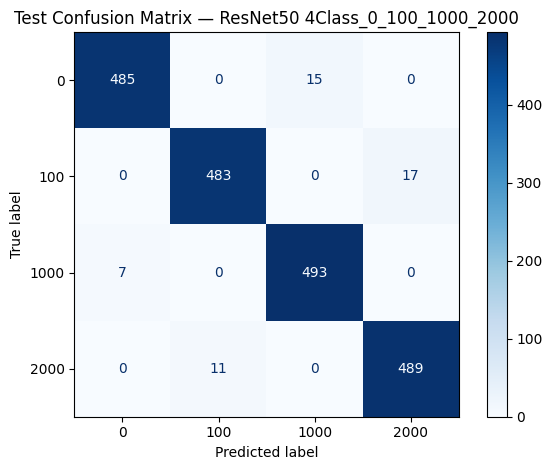


Classification Report — ResNet50:
              precision    recall  f1-score   support

           0     0.9858    0.9700    0.9778       500
         100     0.9777    0.9660    0.9718       500
        1000     0.9705    0.9860    0.9782       500
        2000     0.9664    0.9780    0.9722       500

    accuracy                         0.9750      2000
   macro avg     0.9751    0.9750    0.9750      2000
weighted avg     0.9751    0.9750    0.9750      2000



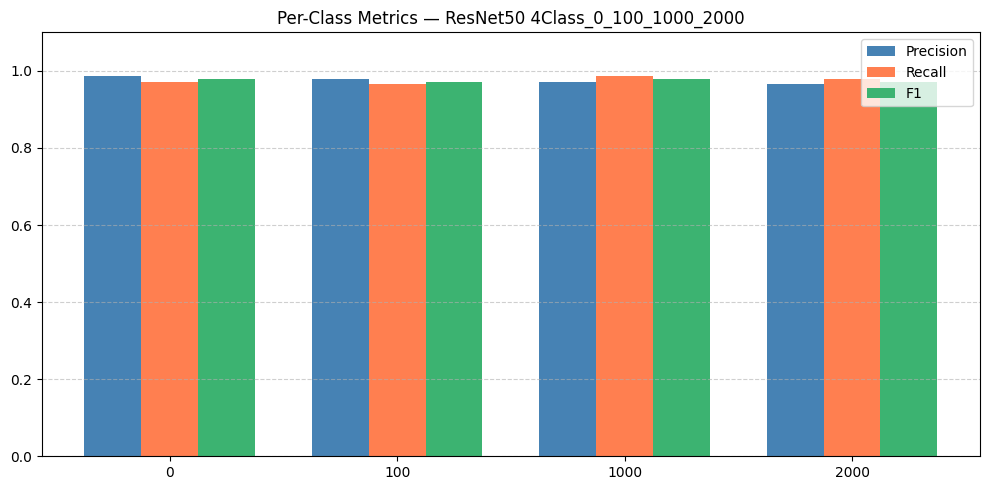

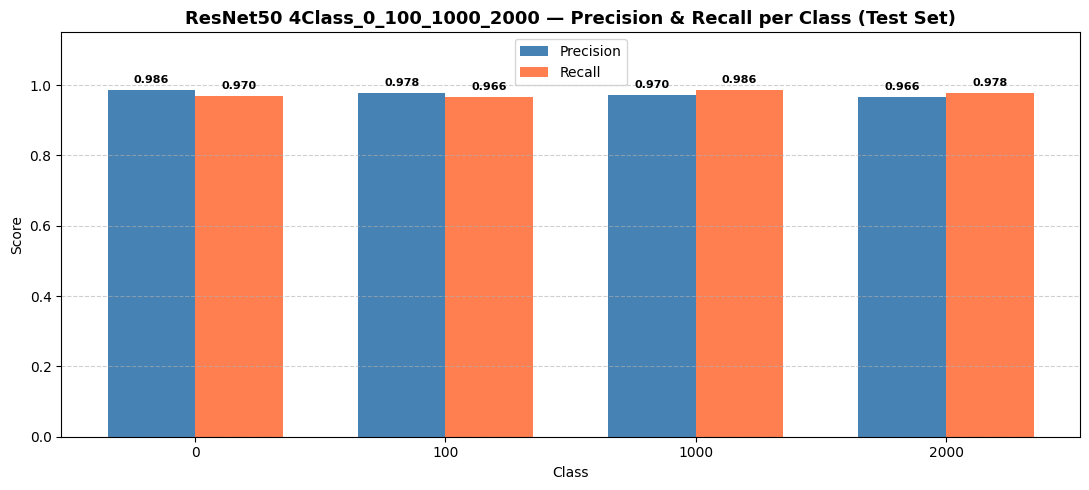

Precision & recall graph saved.


/tmp/ipykernel_13181/3283344312.py:124: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):
/tmp/ipykernel_13181/3283344312.py:137: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):



ResNet50 — Inference Time per Image
  Images timed : 100
  Average      : 4.981 ms / image
  Std Dev      : 0.419 ms
  Min          : 4.466 ms
  Max          : 6.253 ms

FINAL SUMMARY
Accuracy           : 97.50%
Macro Precision    : 97.51%
Macro Recall       : 97.50%
Macro F1-score     : 97.50%
Parameters         : 23,770,820 total | 23,770,820 trainable
Model size         : 90.994 MB
Inference time     : 4.981 ms/image
Device             : cuda | NVIDIA GeForce RTX 3050 Ti Laptop GPU
Results saved in: /home/jenarththan/Desktop/FYP/May11/Notebooks/ResNet50_4C_0_100_1000_2000_May11_Results


In [6]:
# ================================================
# Cell 6 — Test Evaluation + Reports + Graphs + Inference Time
# ================================================
model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

all_preds, all_labels, all_probs = [], [], []
sample_idx = 0

print("\n" + "="*65)
print(f"{'#':>6}  {'True Label':>12}  {'Pred Label':>12}  {'Correct':>8}")
print("="*65)

# Disable gradients for inference — saves memory and speeds up evaluation
with torch.no_grad():
    for inputs, labels in tqdm(test_loader, desc="Inference", leave=False):
        inputs = inputs.to(DEVICE, non_blocking=True)
        with torch.cuda.amp.autocast(enabled=use_amp):
            outputs = model(inputs)
        probs = F.softmax(outputs, dim=1).cpu().numpy()
        preds = outputs.argmax(1).cpu().numpy()
        all_preds.extend(preds)
        all_labels.extend(labels.numpy())
        all_probs.extend(probs)
        for i in range(len(preds)):
            true_name = CLASS_NAMES[labels[i]]
            pred_name = CLASS_NAMES[preds[i]]
            correct = "YES" if preds[i] == labels[i].item() else "NO "
            print(f"{sample_idx:>6}  {true_name:>12}  {pred_name:>12}  {correct:>8}")
            sample_idx += 1

print("="*65)

all_preds = np.array(all_preds)
all_labels = np.array(all_labels)
all_probs = np.array(all_probs)
test_acc = (all_preds == all_labels).mean()
print(f"\nTest Accuracy (ResNet50): {test_acc * 100:.2f}%")
print(f"Correct: {(all_preds == all_labels).sum()} / {len(all_labels)}")


# Confusion matrix for the target subclass subset
# ── Confusion Matrix ──
cm = confusion_matrix(all_labels, all_preds, labels=list(range(NUM_CLASSES)))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
disp.plot(cmap='Blues', values_format='d')
plt.title("Test Confusion Matrix — ResNet50 4Class_0_100_1000_2000")
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "confusion_matrix_4class_0_100_1000_2000.png"), dpi=150)
plt.show()


# Per-class precision, recall, F1 for the subclass experiment
# ── Classification Report ──
report_txt = classification_report(all_labels, all_preds, target_names=CLASS_NAMES, digits=4)
print("\nClassification Report — ResNet50:")
print(report_txt)
with open(os.path.join(OUTPUT_DIR, "classification_report_4class_0_100_1000_2000.txt"), "w") as f:
    f.write(report_txt)
report_df = pd.DataFrame(
    classification_report(all_labels, all_preds, target_names=CLASS_NAMES, output_dict=True, digits=4)
).transpose()
report_df.to_csv(os.path.join(OUTPUT_DIR, "classification_report_4class_0_100_1000_2000.csv"))


# Grouped bar charts: precision, recall, F1 per class
# ── Per-class metrics ──
precision = precision_score(all_labels, all_preds, average=None, labels=range(NUM_CLASSES))
recall = recall_score(all_labels, all_preds, average=None, labels=range(NUM_CLASSES))
f1 = f1_score(all_labels, all_preds, average=None, labels=range(NUM_CLASSES))
x = np.arange(NUM_CLASSES)

w = 0.25
plt.figure(figsize=(10, 5))
plt.bar(x - w, precision, w, label='Precision', color='steelblue')
plt.bar(x, recall, w, label='Recall', color='coral')
plt.bar(x + w, f1, w, label='F1', color='mediumseagreen')
plt.xticks(x, CLASS_NAMES)
plt.ylim(0, 1.1)
plt.title("Per-Class Metrics — ResNet50 4Class_0_100_1000_2000")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "per_class_metrics_4class_0_100_1000_2000.png"), dpi=150)
plt.show()

w2 = 0.35
plt.figure(figsize=(11, 5))
plt.bar(x - w2/2, precision, w2, label='Precision', color='steelblue')
plt.bar(x + w2/2, recall, w2, label='Recall', color='coral')
for i in range(NUM_CLASSES):
    plt.text(i - w2/2, precision[i] + 0.02, f'{precision[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
    plt.text(i + w2/2, recall[i] + 0.02, f'{recall[i]:.3f}',
             ha='center', fontsize=8, fontweight='bold')
plt.xticks(x, CLASS_NAMES)
plt.ylim(0, 1.15)
plt.xlabel("Class")
plt.ylabel("Score")
plt.title("ResNet50 4Class_0_100_1000_2000 — Precision & Recall per Class (Test Set)", fontsize=13, fontweight='bold')
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "precision_recall_4class_0_100_1000_2000.png"), dpi=150)
plt.show()
print("Precision & recall graph saved.")


# Save per-sample predictions and softmax probabilities to CSV
# ── Raw predictions CSV ──
pred_df = pd.DataFrame({
    "Sample": range(len(all_labels)),
    "True Label": [CLASS_NAMES[i] for i in all_labels],
    "Pred Label": [CLASS_NAMES[i] for i in all_preds],
    "Correct": (all_preds == all_labels).astype(int),
})
for cls_idx, cls_name in enumerate(CLASS_NAMES):
    pred_df[f"Prob_{cls_name}"] = all_probs[:, cls_idx]
pred_df.to_csv(os.path.join(OUTPUT_DIR, "predictions_4class_0_100_1000_2000.csv"), index=False)

# ================================================
# Inference Time — 100 random test samples, per image
# ================================================
num_timing = min(100, len(test_ds))
_rng100 = np.random.RandomState(SEED)
_sample_idx = _rng100.choice(len(test_ds), num_timing, replace=False)
_timing_loader = DataLoader(Subset(test_ds, _sample_idx), batch_size=1,
                            shuffle=False, num_workers=0, pin_memory=PIN_MEMORY)

# Disable gradients for inference — saves memory and speeds up evaluation
with torch.no_grad():
    _warm, _ = next(iter(_timing_loader))
    _warm = _warm.to(DEVICE)
    with torch.cuda.amp.autocast(enabled=use_amp):
        _ = model(_warm)
if DEVICE.type == "cuda":
    torch.cuda.synchronize()

inference_times_ms = []
model.eval()
# Disable gradients for inference — saves memory and speeds up evaluation
with torch.no_grad():
    for _inp, _ in _timing_loader:
        _inp = _inp.to(DEVICE)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        _t0 = time.perf_counter()
        with torch.cuda.amp.autocast(enabled=use_amp):
            _ = model(_inp)
        if DEVICE.type == "cuda":
            torch.cuda.synchronize()
        inference_times_ms.append((time.perf_counter() - _t0) * 1000)

avg_time_ms = float(np.mean(inference_times_ms))
std_time_ms = float(np.std(inference_times_ms))

print("\n" + "="*58)
print("ResNet50 — Inference Time per Image")
print("="*58)
print(f"  Images timed : {num_timing}")
print(f"  Average      : {avg_time_ms:.3f} ms / image")
print(f"  Std Dev      : {std_time_ms:.3f} ms")
print(f"  Min          : {np.min(inference_times_ms):.3f} ms")
print(f"  Max          : {np.max(inference_times_ms):.3f} ms")
print("="*58)

pd.DataFrame({"sample": range(num_timing), "inference_time_ms": inference_times_ms}).to_csv(
    os.path.join(OUTPUT_DIR, "4class_0_100_1000_2000_inference_times.csv"), index=False)
pd.DataFrame({
    "Stage": ["ResNet50"],
    "Avg_ms_per_image": [round(avg_time_ms, 4)],
    "Std_ms": [round(std_time_ms, 4)],
    "Min_ms": [round(float(np.min(inference_times_ms)), 4)],
    "Max_ms": [round(float(np.max(inference_times_ms)), 4)],
}).to_csv(os.path.join(OUTPUT_DIR, "inference_time_summary.csv"), index=False)


# Export macro/weighted averages with model and device info
# ── Final metrics summary ──
macro_precision = precision_score(all_labels, all_preds, average='macro')
macro_recall = recall_score(all_labels, all_preds, average='macro')
macro_f1 = f1_score(all_labels, all_preds, average='macro')
weighted_precision = precision_score(all_labels, all_preds, average='weighted')
weighted_recall = recall_score(all_labels, all_preds, average='weighted')
weighted_f1 = f1_score(all_labels, all_preds, average='weighted')

metrics_summary = pd.DataFrame([{
    "accuracy": test_acc,
    "macro_precision": macro_precision,
    "macro_recall": macro_recall,
    "macro_f1": macro_f1,
    "weighted_precision": weighted_precision,
    "weighted_recall": weighted_recall,
    "weighted_f1": weighted_f1,
    "avg_inference_ms_per_image": avg_time_ms,
    "total_parameters": TOTAL_PARAMS,
    "trainable_parameters": TRAINABLE_PARAMS,
    "model_size_mb": MODEL_SIZE_MB,
    "device_used": str(DEVICE),
    "graphics_card": gpu_name,
}])
metrics_summary.to_csv(os.path.join(OUTPUT_DIR, "metrics_summary_4class_0_100_1000_2000.csv"), index=False)

print("\nFINAL SUMMARY")
print("=" * 70)
print(f"Accuracy           : {test_acc * 100:.2f}%")
print(f"Macro Precision    : {macro_precision * 100:.2f}%")
print(f"Macro Recall       : {macro_recall * 100:.2f}%")
print(f"Macro F1-score     : {macro_f1 * 100:.2f}%")
print(f"Parameters         : {TOTAL_PARAMS:,} total | {TRAINABLE_PARAMS:,} trainable")
print(f"Model size         : {MODEL_SIZE_MB:.3f} MB")
print(f"Inference time     : {avg_time_ms:.3f} ms/image")
print(f"Device             : {DEVICE} | {gpu_name}")
print("=" * 70)
print("Results saved in:", OUTPUT_DIR)


In [7]:
# ================================================
# Cell 7 — Feature Extraction  (save embeddings)
# ================================================
# Extract 128-d embeddings for all splits — used for PCA analysis
def extract_embeddings(loader, model, split_name):
    model.eval()
    embs, ys = [], []
    # Disable gradients for inference — saves memory and speeds up evaluation
    with torch.no_grad():
        for inputs, labels in tqdm(loader, desc=f"Extracting [{split_name}]", leave=False):
            inputs = inputs.to(DEVICE, non_blocking=True)
            with torch.cuda.amp.autocast(enabled=use_amp):
                _, emb = model(inputs, return_embedding=True)
            embs.append(emb.cpu().float().numpy())
            ys.append(labels.numpy())
    return np.concatenate(embs, axis=0), np.concatenate(ys, axis=0)

model.load_state_dict(torch.load(BEST_MODEL_PATH, map_location=DEVICE))
model.eval()

train_embs, train_y = extract_embeddings(train_eval_loader, model, "train")
val_embs, val_y = extract_embeddings(val_loader, model, "val")
test_embs, test_y = extract_embeddings(test_loader, model, "test")

print(f"Embedding shapes -> train: {train_embs.shape}  val: {val_embs.shape}  test: {test_embs.shape}")

for name, arr in [
    ("train_embs", train_embs), ("val_embs", val_embs), ("test_embs", test_embs),
    ("train_y", train_y), ("val_y", val_y), ("test_y", test_y),
]:
    np.save(os.path.join(OUTPUT_DIR, f"{name}.npy"), arr)
    print(f"  Saved {name}.npy  shape={arr.shape}")

print("\nAll embeddings saved.")


Extracting [train]:   0%|          | 0/219 [00:00<?, ?it/s]

/tmp/ipykernel_13181/406030973.py:10: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=use_amp):


Extracting [val]:   0%|          | 0/32 [00:00<?, ?it/s]

Extracting [test]:   0%|          | 0/63 [00:00<?, ?it/s]

Embedding shapes -> train: (7000, 128)  val: (1000, 128)  test: (2000, 128)
  Saved train_embs.npy  shape=(7000, 128)
  Saved val_embs.npy  shape=(1000, 128)
  Saved test_embs.npy  shape=(2000, 128)
  Saved train_y.npy  shape=(7000,)
  Saved val_y.npy  shape=(1000,)
  Saved test_y.npy  shape=(2000,)

All embeddings saved.


In [8]:
# ================================================
# Cell 8 — Saved Artifact Listing
# ================================================
# List all output files with sizes for verification
print("\n" + "="*60)
print("ResNet50 saved artifacts")
print("="*60)
for item in sorted(os.listdir(OUTPUT_DIR)):
    path = os.path.join(OUTPUT_DIR, item)
    if os.path.isfile(path):
        size_mb = os.path.getsize(path) / (1024 ** 2)
        print(f"{item:45} {size_mb:10.3f} MB")
    else:
        print(item)
print("="*60)



ResNet50 saved artifacts
4class_0_100_1000_2000_inference_times.csv         0.002 MB
best_4class_0_100_1000_2000_model.pth             90.994 MB
classification_report_4class_0_100_1000_2000.csv      0.000 MB
classification_report_4class_0_100_1000_2000.txt      0.000 MB
confusion_matrix_4class_0_100_1000_2000.png        0.041 MB
inference_time_summary.csv                         0.000 MB
metrics_summary_4class_0_100_1000_2000.csv         0.000 MB
model_device_size_summary.csv                      0.000 MB
per_class_metrics_4class_0_100_1000_2000.png       0.032 MB
precision_recall_4class_0_100_1000_2000.png        0.045 MB
predictions_4class_0_100_1000_2000.csv             0.092 MB
test_embs.npy                                      0.977 MB
test_y.npy                                         0.015 MB
train_embs.npy                                     3.418 MB
train_y.npy                                        0.054 MB
training_curves.png                                0.060 MB
training

Embeddings : (2000, 128)
True labels: (2000,)
Classes    : ['0', '100', '1000', '2000']
PCA output : /home/jenarththan/Desktop/FYP/May11/Notebooks/ResNet50_4C_0_100_1000_2000_May11_Results/PCA_Analysis

Explained variance: PC1=0.524  PC2=0.294  Total=0.818


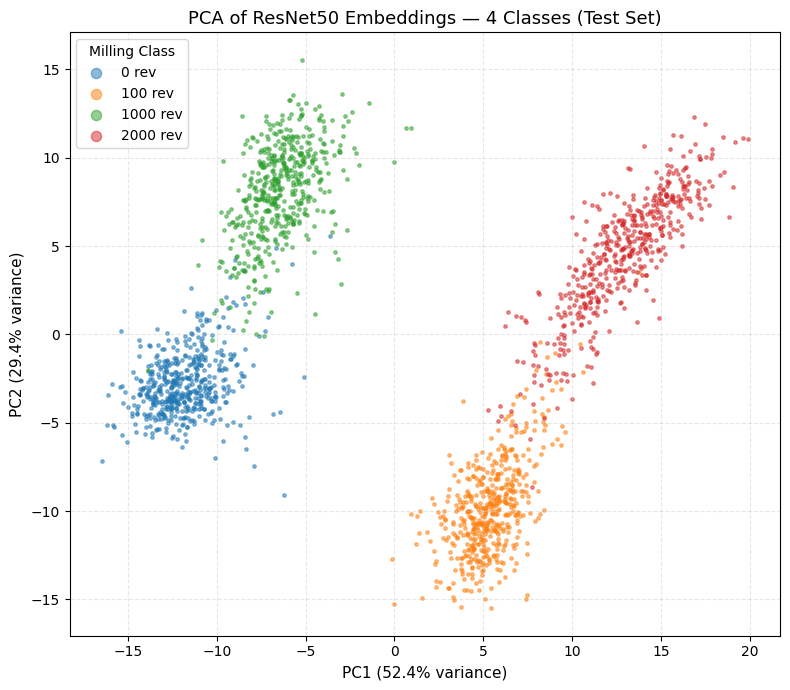

Saved: pca_embeddings.png


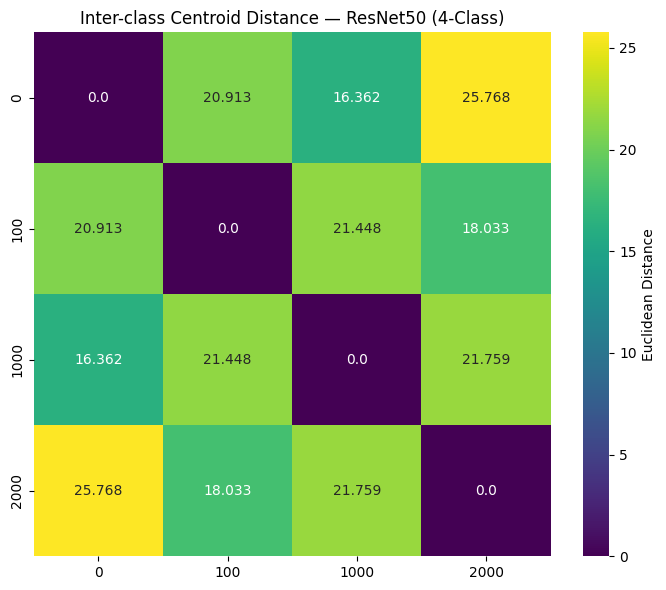

Saved: distance_heatmap.png


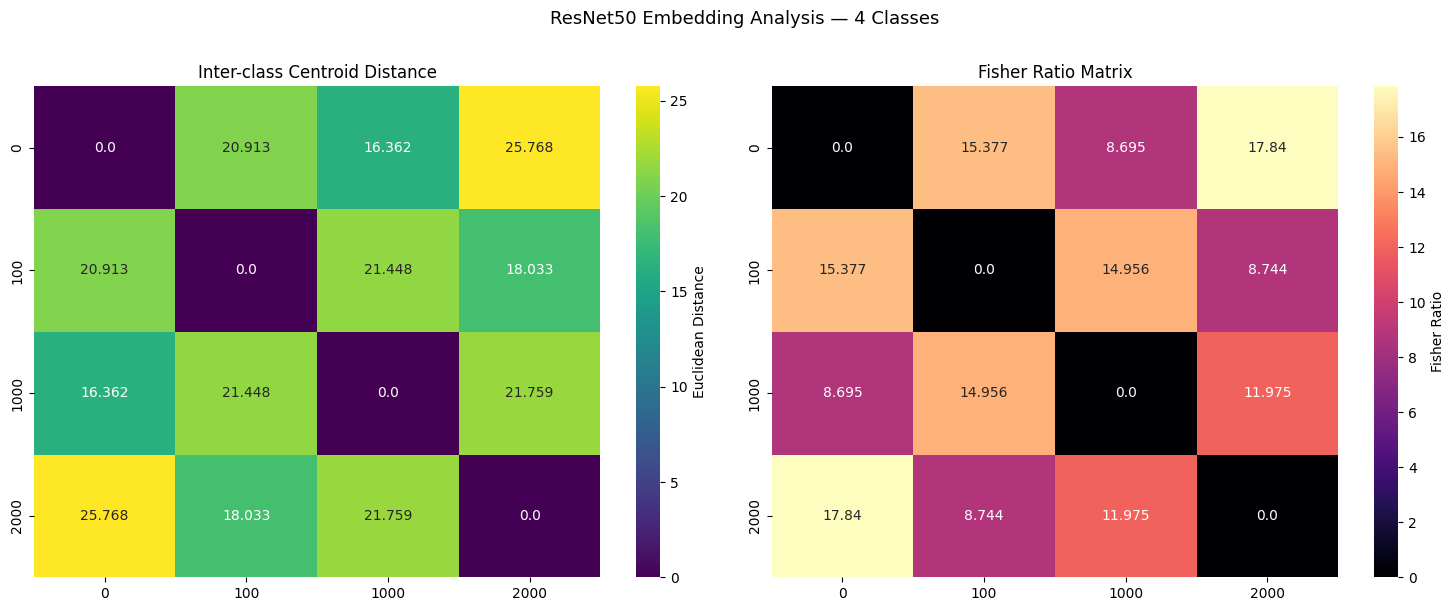

Saved: distance_fisher_side_by_side.png


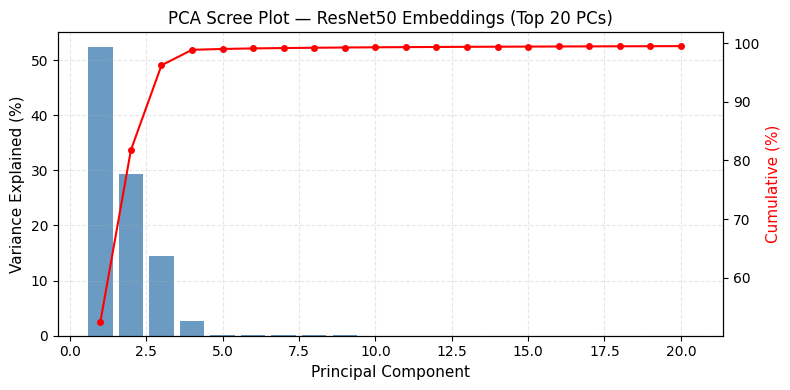

Saved: pca_scree_plot.png

All PCA results saved to: /home/jenarththan/Desktop/FYP/May11/Notebooks/ResNet50_4C_0_100_1000_2000_May11_Results/PCA_Analysis
PC1+PC2 explains : 81.8%
PCs for 95% var  : 3


In [9]:
# ================================================
# Cell 9 — PCA Analysis of Embeddings
# ================================================
# ── PCA analysis libraries ─────────────────────────────────────
# seaborn: heatmaps | scipy: centroid distances | sklearn PCA
import seaborn as sns
from scipy.spatial.distance import cdist
from sklearn.decomposition import PCA
from glob import glob

PCA_DIR = os.path.join(OUTPUT_DIR, "PCA_Analysis")
os.makedirs(PCA_DIR, exist_ok=True)


# Load embeddings from Cell 7 — PCA can be re-run independently
# Load embeddings saved by Cell 7
test_embs = np.load(os.path.join(OUTPUT_DIR, "test_embs.npy"))
y_true    = np.load(os.path.join(OUTPUT_DIR, "test_y.npy"))

# Find predictions CSV saved by Cell 6
pred_csvs = glob(os.path.join(OUTPUT_DIR, "predictions_*.csv"))
assert pred_csvs, f"No predictions CSV found in {OUTPUT_DIR}. Run Cell 6 first."
pred_df   = pd.read_csv(pred_csvs[0])
label_to_idx = {name: i for i, name in enumerate(CLASS_NAMES)}
y_pred = np.array([label_to_idx[str(l)] for l in pred_df["Pred Label"].values])

COLORS = ['#1f77b4','#ff7f0e','#2ca02c','#d62728','#9467bd','#8c564b'][:NUM_CLASSES]

print(f"Embeddings : {test_embs.shape}")
print(f"True labels: {y_true.shape}")
print(f"Classes    : {CLASS_NAMES}")
print(f"PCA output : {PCA_DIR}")


# ── PCA 2-D projection ─────────────────────────────────────────
# Visualises how well the subclass embeddings are separated.
# Tighter, more distinct clusters than the 6-class model are expected.
# ── PCA 2D scatter ──────────────────────────────
pca = PCA(n_components=2, random_state=42)
Z   = pca.fit_transform(test_embs)
var = pca.explained_variance_ratio_
print(f"\nExplained variance: PC1={var[0]:.3f}  PC2={var[1]:.3f}  Total={var.sum():.3f}")

fig, ax = plt.subplots(figsize=(8, 7))
for i, name in enumerate(CLASS_NAMES):
    idx = (y_true == i)
    ax.scatter(Z[idx, 0], Z[idx, 1], s=6, alpha=0.5, label=f'{name} rev', color=COLORS[i])
ax.set_title(f'PCA of ResNet50 Embeddings — {NUM_CLASSES} Classes (Test Set)', fontsize=13)
ax.set_xlabel(f'PC1 ({var[0]*100:.1f}% variance)', fontsize=11)
ax.set_ylabel(f'PC2 ({var[1]*100:.1f}% variance)', fontsize=11)
ax.legend(markerscale=3, fontsize=10, title='Milling Class')
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "pca_embeddings.png"), dpi=300)
plt.show()
print("Saved: pca_embeddings.png")


# Inter-class centroid distances in 128-d embedding space
# ── Centroid distances ──────────────────────────
centroids, intra_spread = [], []
for i in range(NUM_CLASSES):
    Xc = test_embs[y_true == i]
    mu = Xc.mean(axis=0)
    centroids.append(mu)
    intra_spread.append(np.mean(np.linalg.norm(Xc - mu, axis=1)))
centroids    = np.vstack(centroids)
intra_spread = np.array(intra_spread)

inter   = cdist(centroids, centroids, metric='euclidean')
dist_df = pd.DataFrame(inter, index=CLASS_NAMES, columns=CLASS_NAMES)

fig, ax = plt.subplots(figsize=(7, 6))
sns.heatmap(dist_df.round(3), annot=True, fmt='', cmap='viridis', ax=ax,
            cbar_kws={'label': 'Euclidean Distance'})
ax.set_title(f'Inter-class Centroid Distance — ResNet50 ({NUM_CLASSES}-Class)', fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "distance_heatmap.png"), dpi=300)
plt.show()
print("Saved: distance_heatmap.png")


# Fisher ratio: inter-class separation relative to intra-class spread
# ── Fisher ratio ────────────────────────────────
intra_var = intra_spread ** 2
F = np.zeros((NUM_CLASSES, NUM_CLASSES))
for a in range(NUM_CLASSES):
    for b in range(NUM_CLASSES):
        if a != b:
            F[a, b] = (inter[a, b] ** 2) / (intra_var[a] + intra_var[b] + 1e-8)
fish_df = pd.DataFrame(F, index=CLASS_NAMES, columns=CLASS_NAMES)


# Distance and Fisher heatmaps combined for the paper figure
# ── Side-by-side ────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 6))
sns.heatmap(dist_df.round(3), annot=True, fmt='', cmap='viridis', ax=axes[0],
            cbar_kws={'label': 'Euclidean Distance'})
axes[0].set_title('Inter-class Centroid Distance', fontsize=12)
sns.heatmap(fish_df.round(3), annot=True, fmt='', cmap='magma', ax=axes[1],
            cbar_kws={'label': 'Fisher Ratio'})
axes[1].set_title('Fisher Ratio Matrix', fontsize=12)
fig.suptitle(f'ResNet50 Embedding Analysis — {NUM_CLASSES} Classes', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "distance_fisher_side_by_side.png"), dpi=300, bbox_inches='tight')
plt.show()
print("Saved: distance_fisher_side_by_side.png")


# PCA scree plot: variance per component and cumulative variance
# ── Scree plot ──────────────────────────────────
pca_full = PCA(random_state=42).fit(test_embs)
cum_var  = np.cumsum(pca_full.explained_variance_ratio_)
fig, ax  = plt.subplots(figsize=(8, 4))
ax.bar(range(1, 21), pca_full.explained_variance_ratio_[:20]*100, color='steelblue', alpha=0.8, label='Individual')
ax2 = ax.twinx()
ax2.plot(range(1, 21), cum_var[:20]*100, color='red', marker='o', ms=4, label='Cumulative')
ax.set_xlabel('Principal Component', fontsize=11)
ax.set_ylabel('Variance Explained (%)', fontsize=11)
ax2.set_ylabel('Cumulative (%)', fontsize=11, color='red')
ax.set_title('PCA Scree Plot — ResNet50 Embeddings (Top 20 PCs)', fontsize=12)
ax.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.savefig(os.path.join(PCA_DIR, "pca_scree_plot.png"), dpi=150)
plt.show()
print("Saved: pca_scree_plot.png")


# Export all PCA results to CSV for further analysis
# ── Save CSVs ───────────────────────────────────
dist_df.to_csv(os.path.join(PCA_DIR, "pairwise_centroid_distance.csv"))
fish_df.to_csv(os.path.join(PCA_DIR, "pairwise_fisher_ratio.csv"))
pd.DataFrame({'Class': CLASS_NAMES, 'Intra_spread': intra_spread.round(4),
              'N_samples': [int(np.sum(y_true == i)) for i in range(NUM_CLASSES)]
}).to_csv(os.path.join(PCA_DIR, "class_spread_summary.csv"), index=False)
pd.DataFrame({'PC1': Z[:,0], 'PC2': Z[:,1],
              'True_Label': [CLASS_NAMES[i] for i in y_true]
}).to_csv(os.path.join(PCA_DIR, "pca_coordinates.csv"), index=False)

print(f"\nAll PCA results saved to: {PCA_DIR}")
n_95 = int(np.searchsorted(cum_var, 0.95)) + 1
print(f"PC1+PC2 explains : {cum_var[1]*100:.1f}%")
print(f"PCs for 95% var  : {n_95}")